In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd {_repo_root[0]}
del _repo_root

/Users/alex.shtoff/git/spectral_neuron_paper


# HIGGS scaling

Reader-facing companion for the dense HIGGS repeated-shuffle scaling experiment. It validates raw result completeness, performs validation-only learning-rate selection, and compares parameter-matched spectral and constant-width MLP families. It makes no empirical claim until a complete result file has been loaded and the cells have run.

## Setup

In [2]:
import warnings

import matplotlib as mpl
import numpy as np
import pandas as pd

from paper.experiments.higgs_scaling import (
    PROFILES,
    default_raw_path,
    select_lr,
    summarize_raw,
    validate_raw,
)
from paper.plotting import (
    plot_higgs_models_by_dimension,
    plot_higgs_spectral_dimensions,
)

mpl.rcParams["figure.dpi"] = 140

In [3]:
profile_name = "full"
variant = None  # Or one model name to inspect a single-family shard.
profile = PROFILES[profile_name]
raw_path = default_raw_path(profile_name, variant)
metric = "logloss"  # Or "brier".

## Context and assumptions

- Rows 0–9,999,999 train the models, the next 500,000 form validation, and the official final 500,000 rows form test. File order is not time.
- Means and standard deviations are fitted once on the complete training partition and then fixed for every checkpoint and model.
- A trajectory consumes a deterministic stream of fresh permutations over the fixed 10,000,000-row training pool. The x-axis is cumulative examples seen by the optimizer, not independently fitted dataset size.
- The explicit profile `train_sizes` are the only evaluation checkpoints and their maximum is the final budget. The full profile evaluates its requested power-of-two grid through `2**24` and stops there; because that exceeds the training-pool size, the stream automatically draws the remainder from a second shuffle. Pass boundaries do not add checkpoints, and global minibatches may cross them.
- At every checkpoint, median validation log loss across tuning seeds selects a learning rate separately for each model family and capacity. Evaluation starts from fresh initializations; checkpoints selecting the same rate share a trajectory, but a plotted line may stitch checkpoints from different trajectories when the selected rate changes. It is a validation-selected performance envelope, not one coherent training path.
- Lines are medians across paired data-order and initialization seeds; bands are interquartile seed variation on one fixed test partition, not confidence intervals for a test population.

## Load and validate results

In [5]:
if not raw_path.exists():
    raise FileNotFoundError(
        f"{raw_path} does not exist; run paper.experiments.higgs_scaling first"
    )

raw = pd.read_csv(raw_path)
validate_raw(raw, profile, variant)
print(raw_path)

notebooks/runs/higgs_scaling_full_repeated_shuffle.csv


## Validation selection and recorded capacity

In [6]:
selected = select_lr(raw)
selected_lrs = (
    selected[["train_size", "model", "dim", "selected_lr"]]
    .drop_duplicates()
    .sort_values(["train_size", "dim", "model"], kind="stable")
)
boundaries = selected_lrs.loc[
    np.isclose(selected_lrs["selected_lr"], min(profile.lrs))
    | np.isclose(selected_lrs["selected_lr"], max(profile.lrs))
]
if not boundaries.empty:
    warnings.warn(
        "selected learning rate touches the tuning-grid boundary for:\n"
        + boundaries.to_string(index=False),
        stacklevel=1,
    )

capacity_table = (
    selected[["model", "dim", "width", "num_parameters"]]
    .drop_duplicates()
    .sort_values(["dim", "model"], kind="stable")
    .reset_index(drop=True)
)
capacity_table

/var/folders/q7/013yg76j1k70_sx9x7gxtkz00000gn/T/ipykernel_44581/1186846840.py:12: UserWarning: selected learning rate touches the tuning-grid boundary for:
 train_size    model  dim  selected_lr
       4096   linear    0          0.1
       4096    mlp-1    3          0.1
       4096    mlp-2    3          0.1
       4096    mlp-3    3          0.1
       4096 spectral    3          0.1
      16384   linear    0          0.1
      16384    mlp-1    3          0.1
      16384    mlp-2    3          0.1
      16384    mlp-3    3          0.1
      65536   linear    0          0.1
      65536    mlp-1    3          0.1
      65536    mlp-2    3          0.1
      65536    mlp-3    3          0.1
     262144    mlp-1    3          0.1
     262144    mlp-3    3          0.1
  warnings.warn(


,model,dim,width,num_parameters
0,linear,0,0,29
1,mlp-1,3,6,181
2,mlp-2,3,5,181
3,mlp-3,3,4,161
4,spectral,3,0,174
5,mlp-1,7,27,811
6,mlp-2,7,17,817
7,mlp-3,7,14,841
8,spectral,7,0,812
9,mlp-1,11,64,1921


## Selected test summary

In [7]:
summary = summarize_raw(raw)
summary[[
    "train_pool_size", "train_size", "model", "dim", "width", "num_parameters",
    "selected_lr", "median_test_logloss", "q25_test_logloss",
    "q75_test_logloss", "median_test_brier", "q25_test_brier",
    "q75_test_brier", "n",
]].sort_values(["train_size", "dim", "model"], kind="stable")

,train_pool_size,train_size,model,dim,width,num_parameters,selected_lr,median_test_logloss,q25_test_logloss,q75_test_logloss,median_test_brier,q25_test_brier,q75_test_brier,n
0,10000000,4096,linear,0,0,29,0.100000,0.691185,0.684087,0.696076,0.248780,0.245476,0.251189,24
10,10000000,4096,mlp-1,3,6,181,0.100000,0.689382,0.684747,0.693640,0.248086,0.245715,0.250164,24
40,10000000,4096,mlp-2,3,5,181,0.100000,0.691187,0.690529,0.694984,0.248959,0.248607,0.250899,24
70,10000000,4096,mlp-3,3,4,161,0.100000,0.690680,0.688961,0.693923,0.248768,0.247916,0.250388,24
100,10000000,4096,spectral,3,0,174,0.100000,0.694393,0.687333,0.712088,0.250087,0.246669,0.258177,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,10000000,67108864,spectral,7,0,812,0.005179,0.536922,0.536626,0.537572,0.180878,0.180767,0.181178,24
39,10000000,67108864,mlp-1,11,64,1921,0.005179,0.515212,0.514792,0.515918,0.172206,0.172053,0.172466,24
69,10000000,67108864,mlp-2,11,31,1923,0.005179,0.503397,0.502532,0.504404,0.167969,0.167563,0.168299,24
99,10000000,67108864,mlp-3,11,24,1921,0.005179,0.504395,0.504019,0.504757,0.168391,0.168176,0.168534,24


## Scaling curves

The matched-family plot requires the merged result rather than an individual variant shard. Facet annotations are read from `width` and `num_parameters` in the selected rows; they are not reconstructed from a lookup table.

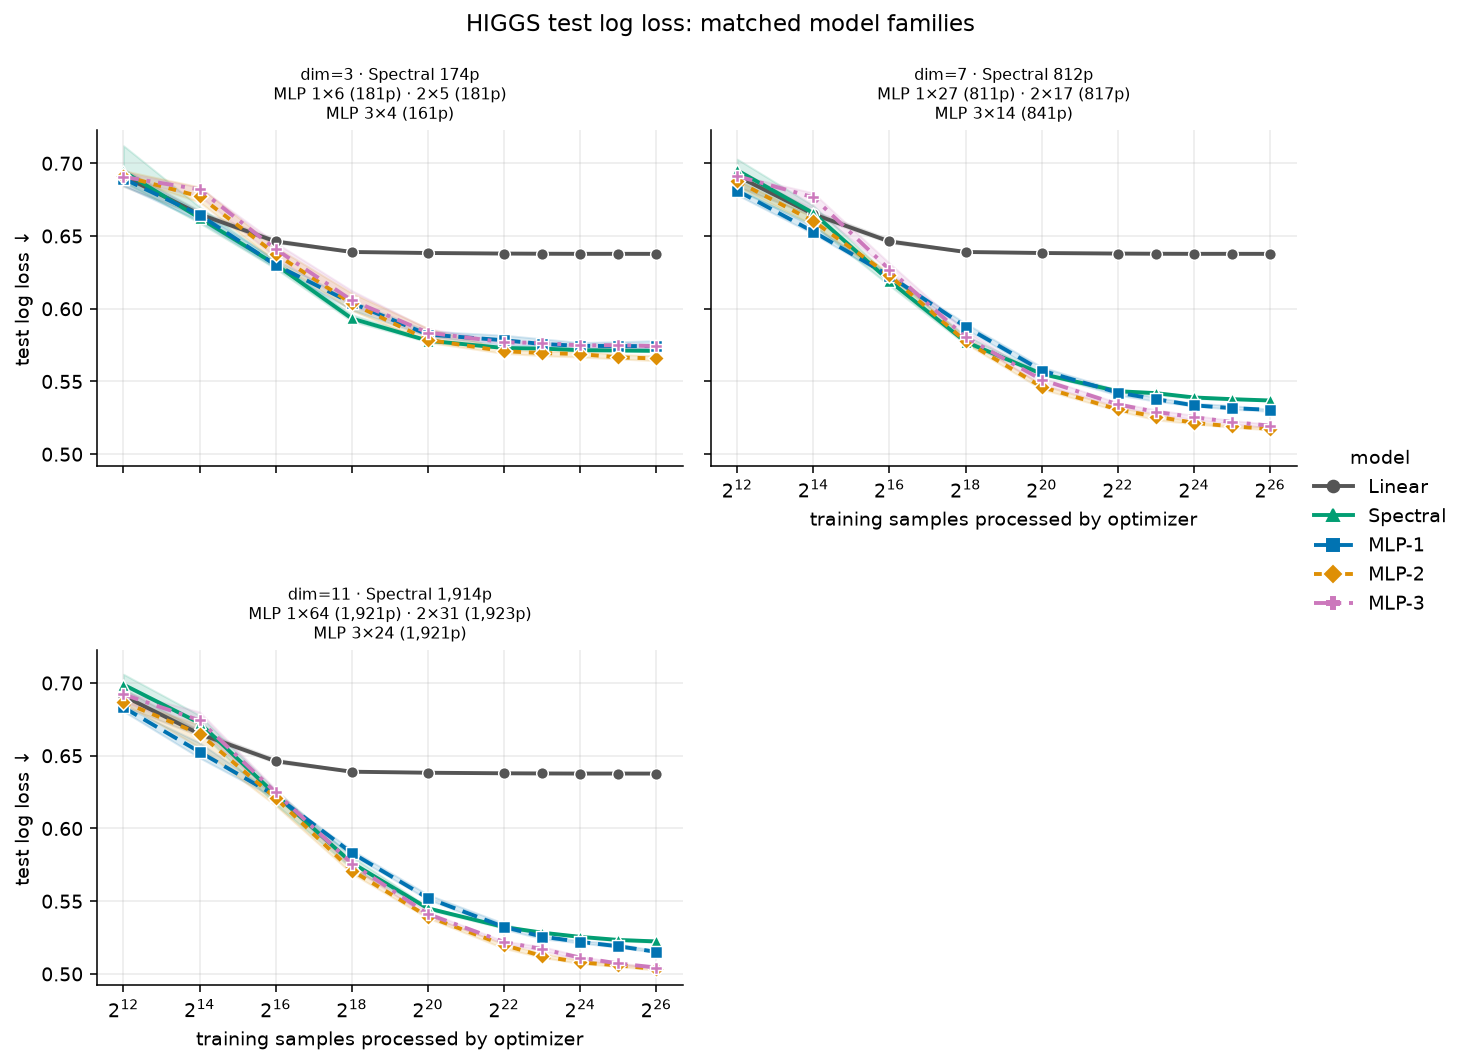

In [8]:
if variant is None:
    plot_higgs_models_by_dimension(selected, metric=metric)
else:
    print(
        "Matched-family facets require the merged result; "
        "set variant=None after appending all family shards."
    )

### Spectral dimensions on one axis

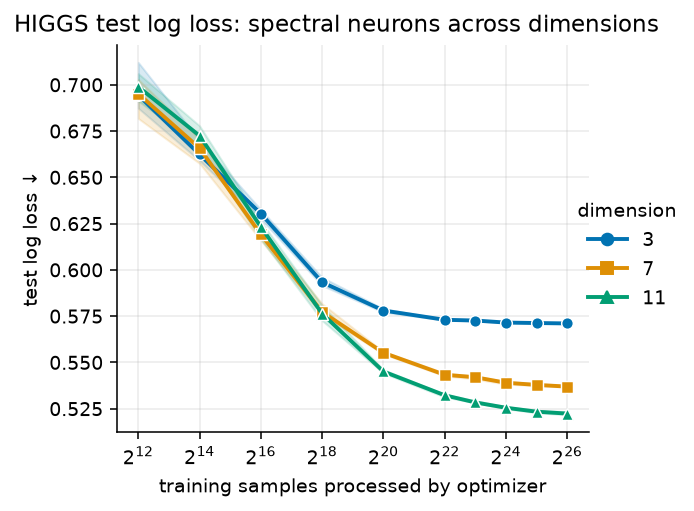

In [9]:
if variant in (None, "spectral"):
    plot_higgs_spectral_dimensions(selected, metric=metric)
else:
    print(
        "Spectral-dimension comparison requires the merged result or "
        "the spectral shard."
    )

## Reading the figure

Each facet holds the spectral dimension—and therefore the target parameter budget—fixed. The linear trajectory is repeated as a common reference. The annotation reports the actual spectral parameter count and each MLP's recorded depth, width, and parameter count. The one-axis spectral plot compares the matrix dimensions directly against cumulative examples seen, including prefixes drawn from later shuffled permutations once exposure exceeds the recorded `train_pool_size`. Change `metric` in Setup to `"brier"` for the corresponding Brier-score view. Any substantive empirical interpretation should be written only after this notebook has executed against the complete result file.